In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-20-01-2026-om3-update/cm3-datastore/cm3-datastore.json'
# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'

# esm_file= os.path.join(run_dir, 'cm3-demo-datastore/cm3-virtual-datastore.json')
plotfolder='/g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-20-01-2026-om3-update/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/


In [31]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import dask.array as da
from itables import show
import h5py

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


In [5]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
# datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

# for col in COLUMNS_WITH_ITERABLES:
#     datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

# df = available_variables(datastore_filtered)
# show(df)

# Load ocean and atmosphere areas

In [8]:
wet = datastore.search(variable="wet").to_dask().compute()
areacello = datastore.search(variable="areacello").to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

In [9]:
EARTH_RADIUS = 6371229.0
nlon, nlat = 192, 144
dx = 360 / nlon
dy = 180 / nlat

element_lat = (np.arange(nlat) + 0.5) * dy  - 90
element_lat = element_lat[:, None] * np.ones(nlon)[None, :]
element_lon = (np.arange(nlon) + 0.5) * dx

pi_over_180 = np.pi / 180
element_areas = dx * pi_over_180 * (
  np.sin((element_lat + 0.5 * dy) * pi_over_180) - np.sin((element_lat - 0.5 * dy) * pi_over_180)
)

areacella = element_areas * EARTH_RADIUS**2
areacella = xr.DataArray(areacella, coords=dict(lat=element_lat[:, 0], lon=element_lon), dims=('lat', 'lon'))

total_ocn_fraction = areacello.sum().data / areacella.sum().data

# Ocean time series

## Ocean heatflux

## Load CM3 data

In [10]:
cm3_ocean_heatflux = datastore.search(variable="net_heat_coupler", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).net_heat_coupler

In [37]:
# area weighted average of ocean heatflux
# average over entire earth for comparison with TOA
cm3_avg_ocean_heatflux = cm3_ocean_heatflux.weighted(areacello.fillna(0)).mean(dim=('yh', 'xh')).compute() * total_ocn_fraction

### Load CM2 data

In [22]:
def load_cm2_data(var_name, year_start, year_end):

    da_list = []

    for year in range(year_start, year_end):
        for month in [1, 7]:
            
            fn = f'ocean-2d-{var_name}-1-monthly-mean-ym_{str(year).zfill(4)}_0{month}.nc'
            fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/{fn}'
            da_list.append(xr.open_dataset(fp, drop_variables=["average_T1", "average_T2"], chunks="auto")[var_name])

    return xr.concat(da_list, dim='time')


cm2_heatflux = load_cm2_data('sfc_hflux_coupler', 1, 51).rename(yt_ocean="yh", xt_ocean="xh")

In [23]:
fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/ocean-2d-area_t.nc'
cm2_area = xr.open_dataset(fp).area_t.data
cm2_area = xr.DataArray(cm2_area, coords=dict(yh=cm2_heatflux.yh, xh=cm2_heatflux.xh), dims=('yh', 'xh'))

In [15]:
cm2_avg_ocean_heatflux = cm2_heatflux.weighted(cm2_area.fillna(0)).mean(dim=('yh', 'xh')).compute() * total_ocn_fraction

### Plot

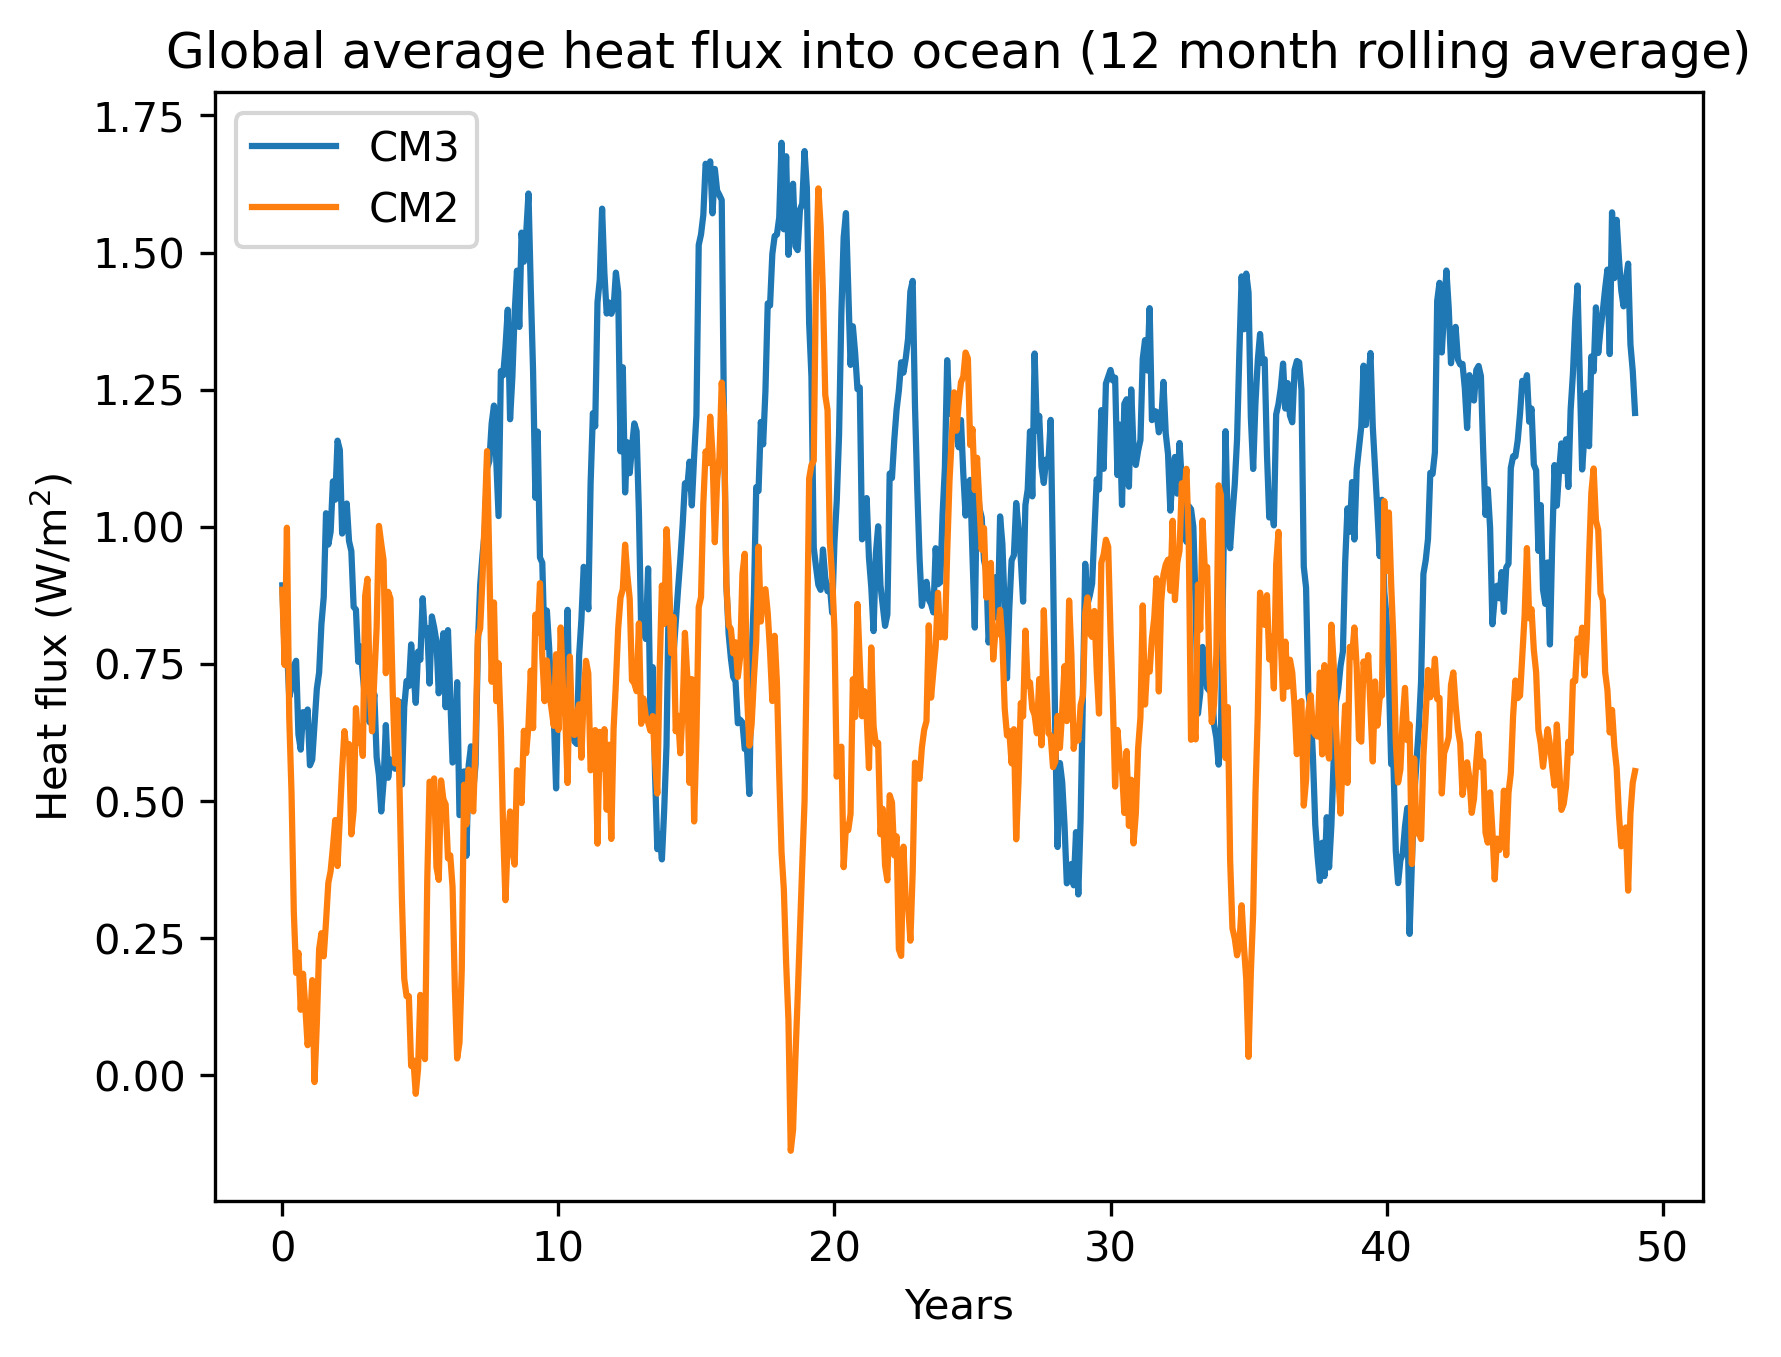

In [16]:
N = 12
rolling_avg = np.convolve(cm3_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label="CM3")

rolling_avg = np.convolve(cm2_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label="CM2")

plt.title('Global average heat flux into ocean (12 month rolling average)')
plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')
plt.legend()

## SST

In [17]:
cm3_avg_sst = datastore.search(variable="tosga", frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        decode_timedelta=True
    )
).tosga.compute()

In [18]:
year_start = 1
year_end = 51
da_list = []

for year in range(year_start, year_end):
    for month in [1, 7]:
        
        fn = f'ocean-scalar-1-daily-ym_{str(year).zfill(4)}_0{month}.nc'
        da_list.append(xr.open_dataset(f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/{fn}')['temp_surface_ave'])

cm2_avg_sst = xr.concat(da_list, dim='time').data[:, 0]

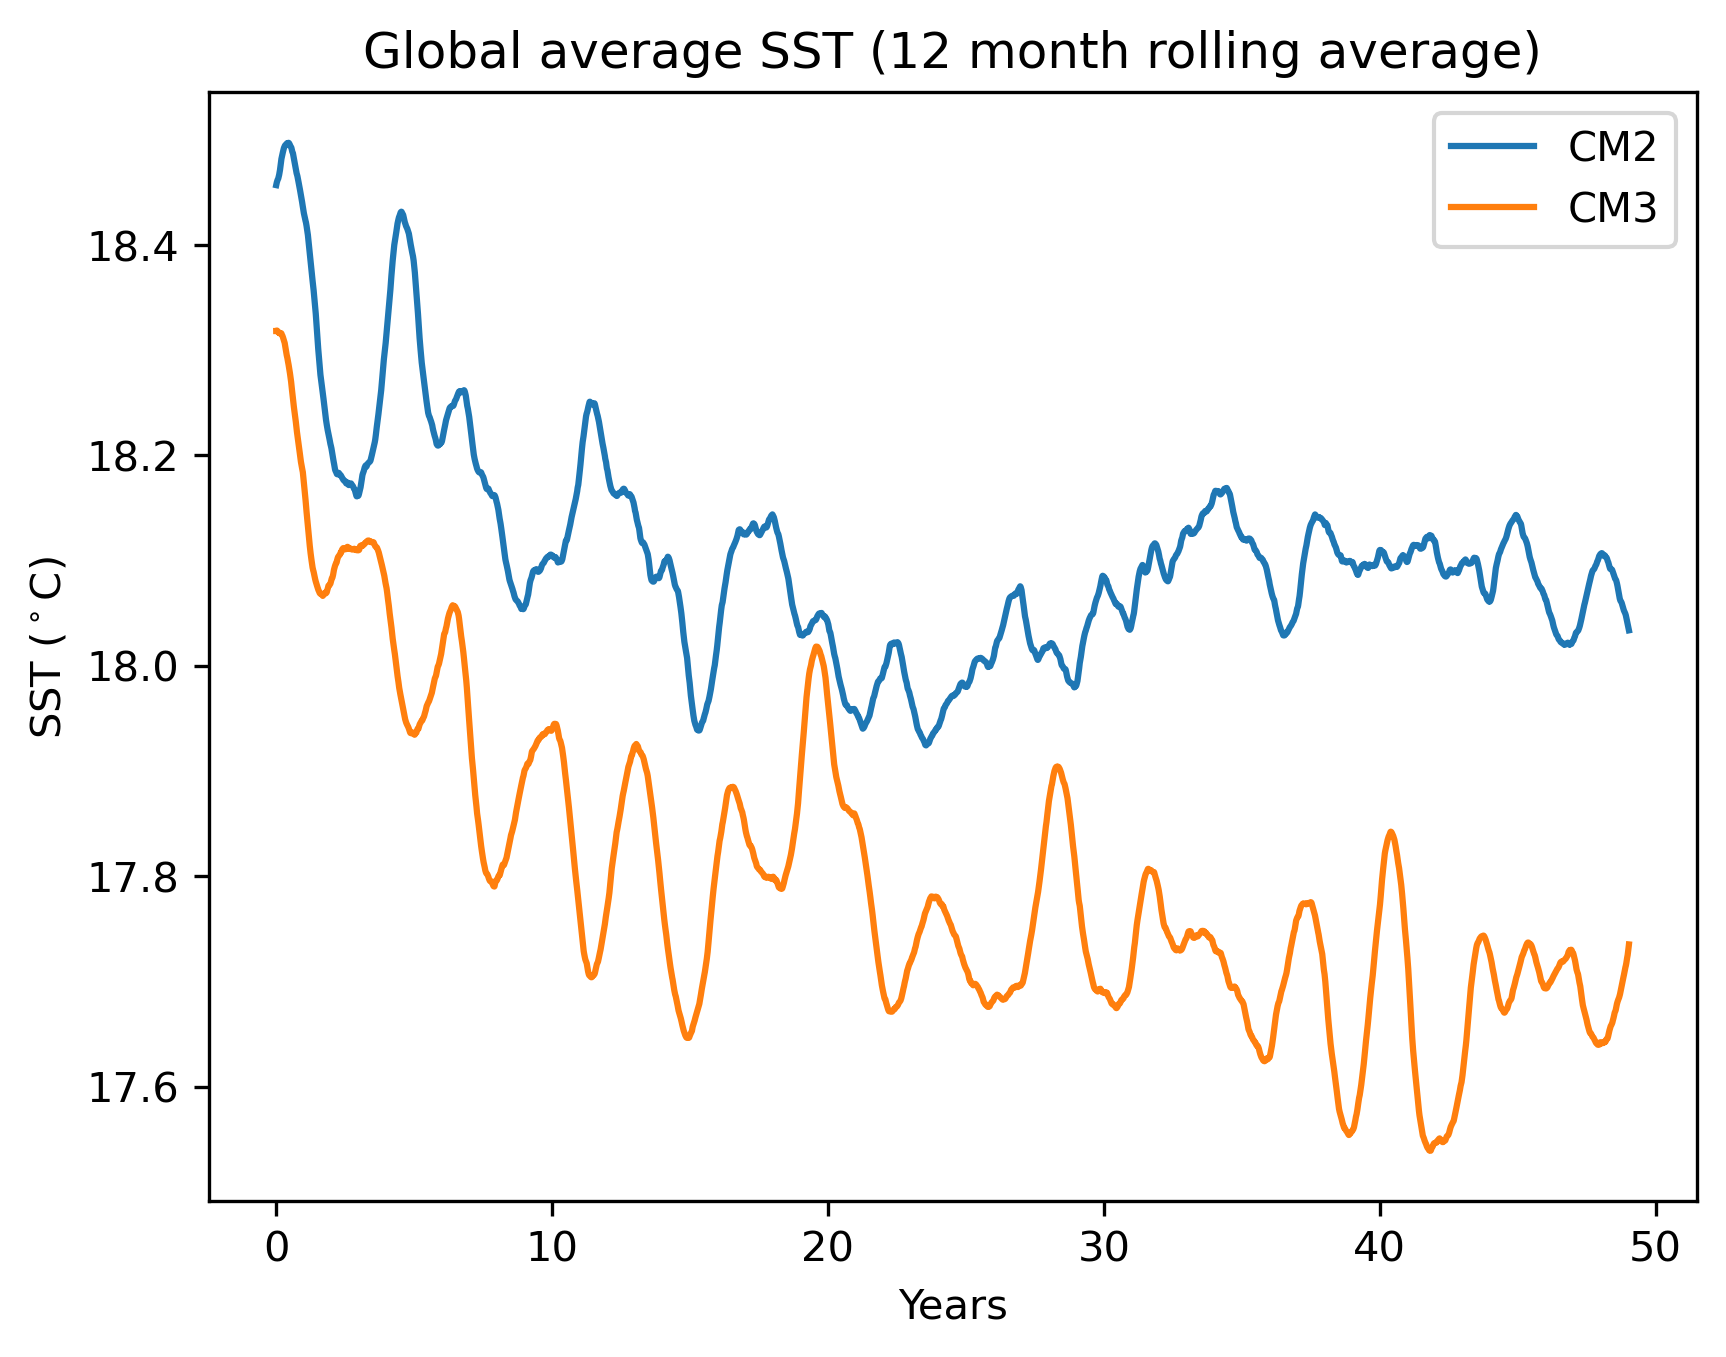

In [19]:
N = 365
avg_flx = np.convolve(cm2_avg_sst, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(avg_flx)) / N, avg_flx, label='CM2')

avg_flx = np.convolve(cm3_avg_sst.data.ravel(), np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(avg_flx)) / N, avg_flx, label='CM3')

plt.title('Global average SST (12 month rolling average)')

plt.xlabel('Years')
plt.ylabel('SST ($^\circ$C)')
plt.legend()

# Ice time series

## Ice area

### Load CM3 data

In [20]:
cm3_ice_fraction = datastore.search(variable="aice_m", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"nj": -1, "ni": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).aice_m

In [11]:
cm3_sh_mask = areacello.data.copy()
cm3_sh_mask[cm3_sh_mask.data.shape[0]//2:] = 0
cm3_sh_mask = xr.DataArray(cm3_sh_mask, dims=('nj', 'ni')).fillna(0)

cm3_nh_mask = areacello.data.copy()
cm3_nh_mask[:cm3_nh_mask.data.shape[0]//2] = 0
cm3_nh_mask = xr.DataArray(cm3_nh_mask, dims=('nj', 'ni')).fillna(0)

In [22]:
%%time
cm3_nh_ice_area = cm3_ice_fraction.weighted(cm3_nh_mask).sum(dim=('nj', 'ni')).compute()
cm3_sh_ice_area = cm3_ice_fraction.weighted(cm3_sh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 13.2 s, sys: 3.5 s, total: 16.7 s
Wall time: 2min 20s


### Load CM2 data

In [24]:
cm2_sh_mask = cm2_area.data.copy()
cm2_sh_mask[cm2_sh_mask.data.shape[0]//2:] = 0
cm2_sh_mask = xr.DataArray(cm2_sh_mask, dims=('nj', 'ni')).fillna(0)

cm2_nh_mask = cm2_area.data.copy()
cm2_nh_mask[:cm2_nh_mask.data.shape[0]//2] = 0
cm2_nh_mask = xr.DataArray(cm2_nh_mask, dims=('nj', 'ni')).fillna(0)

In [24]:
year = month = 1
fn = f'iceh_m.{str(year).zfill(4)}-{str(month).zfill(2)}.nc'
fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ice/{fn}'

all_vars = xr.open_dataset(fp).data_vars.keys()

keep_vars = ["aice", "vicen"]
drop_vars = [var for var in all_vars if not var in keep_vars]

In [15]:
%%time
cm2_cice_ds_list = []
year_start = 1
year_end = 50
for year in range(year_start, year_end+1):
    for month in range(1, 13):
        fn = f'iceh_m.{str(year).zfill(4)}-{str(month).zfill(2)}.nc'
        fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ice/{fn}'
        cm2_cice_ds_list.append(xr.open_dataset(fp, chunks=dict(time=1, nc=1, nj=-1, ni=-1)))

CPU times: user 1min 52s, sys: 11.6 s, total: 2min 3s
Wall time: 2min 54s


In [26]:
cm2_aice = xr.DataArray(da.concatenate([ds.aice.data for ds in cm2_cice_ds_list]), dims=('time', 'nj', 'ni'))

In [27]:
%%time
cm2_nh_ice_area = cm2_aice.weighted(cm2_nh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 7.52 s, sys: 1.6 s, total: 9.11 s
Wall time: 1min 8s


In [28]:
%%time
cm2_sh_ice_area = cm2_aice.weighted(cm2_sh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 7.27 s, sys: 2.25 s, total: 9.52 s
Wall time: 1min 15s


### Plot

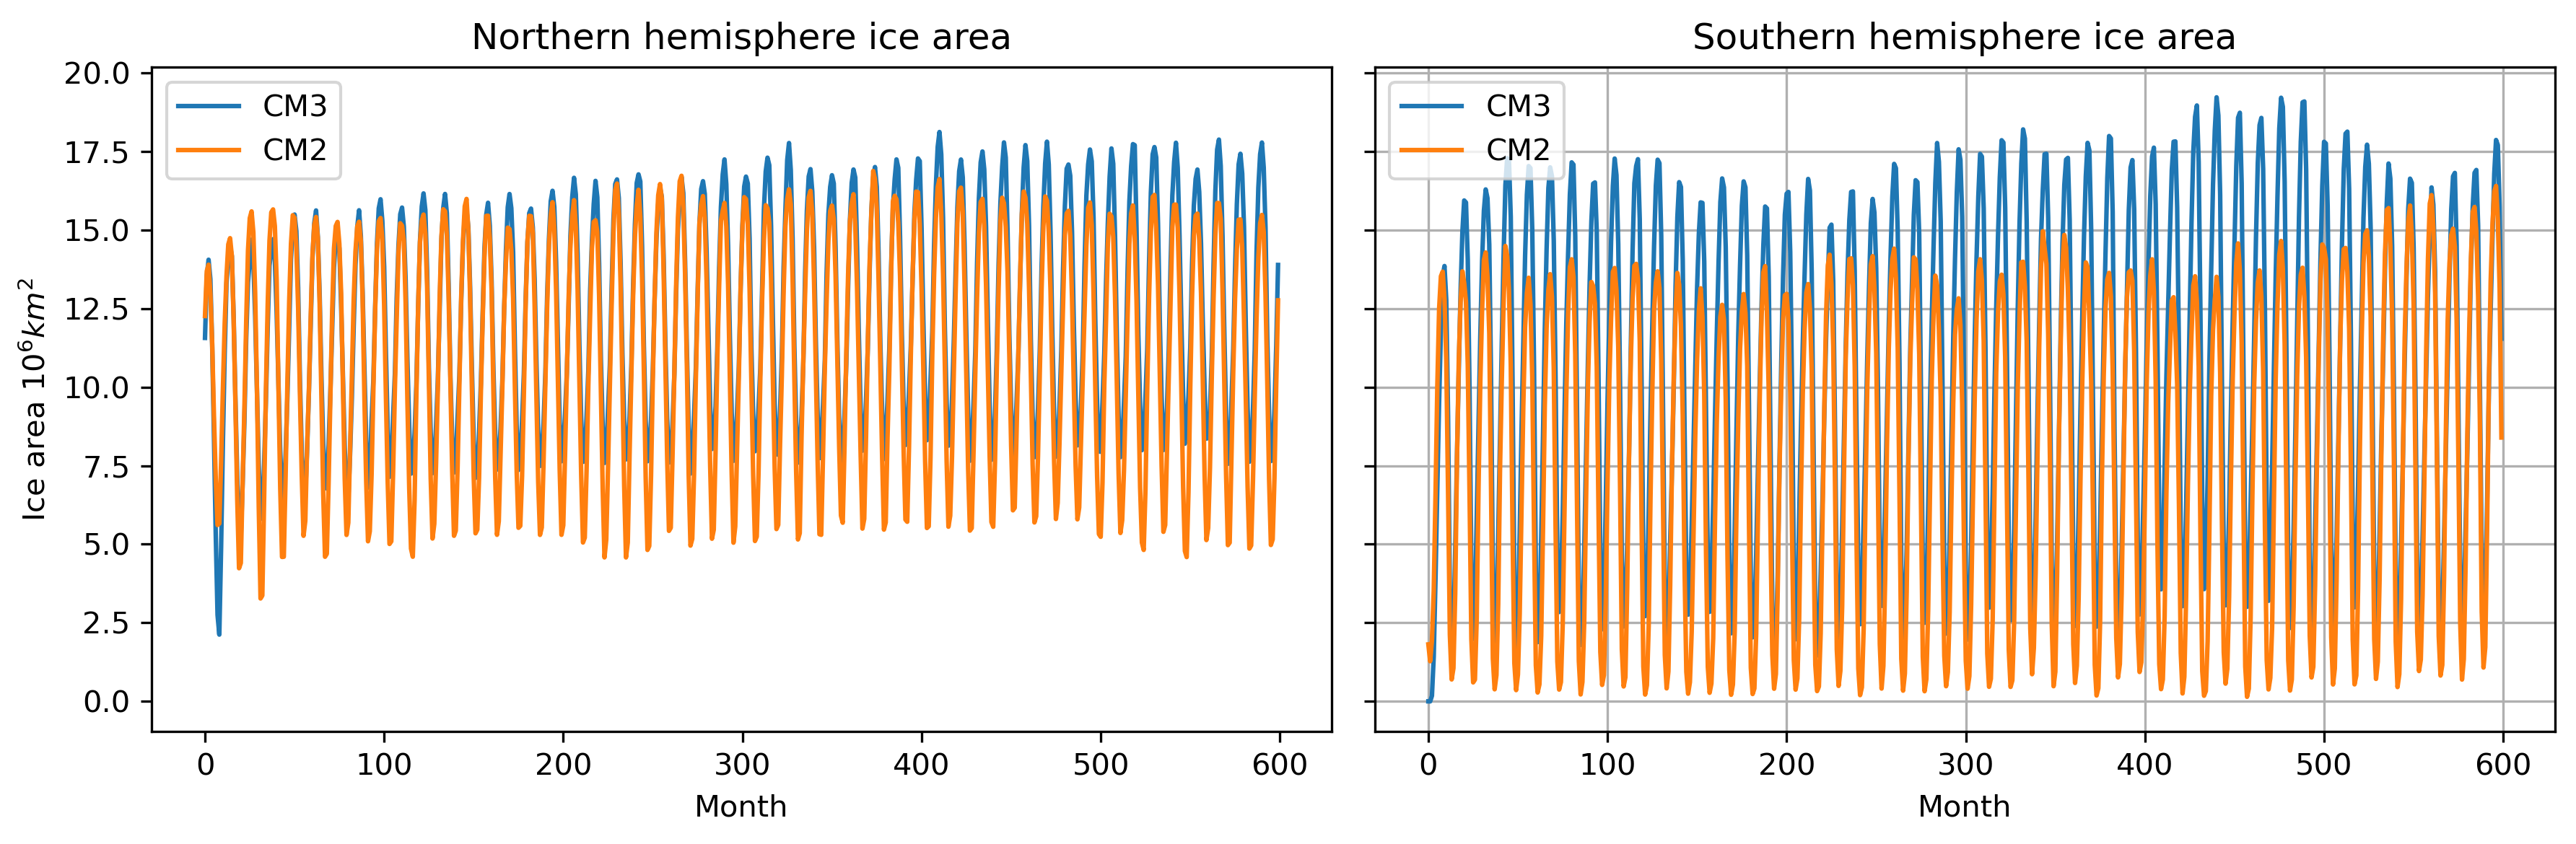

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(cm3_nh_ice_area / 1e12, label='CM3')
ax1.plot(cm2_nh_ice_area / 1e12, label='CM2')
ax2.plot(cm3_sh_ice_area / 1e12, label='CM3')
ax2.plot(cm2_sh_ice_area / 1e12, label='CM2')

ax1.set_title('Northern hemisphere ice area')
ax1.set_ylabel('Ice area $10^6 km^2$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice area')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()
plt.grid()

## Ice volume

### Load CM3 data

In [12]:
cm3_ice_thickness = datastore.search(variable="hi_m", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"nj": -1, "ni": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).hi_m

In [13]:
%%time
cm3_nh_ice_vol = cm3_ice_thickness.weighted(cm3_nh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 6.99 s, sys: 1.92 s, total: 8.91 s
Wall time: 1min 25s


In [14]:
%%time
cm3_sh_ice_vol = cm3_ice_thickness.weighted(cm3_sh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 6.37 s, sys: 1.81 s, total: 8.19 s
Wall time: 1min 21s


### Load CM2 data

In [16]:
cm2_ice_hickness = xr.DataArray(da.concatenate([ds.hi.data for ds in cm2_cice_ds_list]), dims=('time', 'nj', 'ni'))

In [25]:
%%time
cm2_nh_ice_vol = cm2_ice_hickness.weighted(cm2_nh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 9.05 s, sys: 2.25 s, total: 11.3 s
Wall time: 1min 28s


In [26]:
%%time
cm2_sh_ice_vol = cm2_ice_hickness.weighted(cm2_sh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 5.92 s, sys: 1.69 s, total: 7.61 s
Wall time: 1min 2s


### Plot

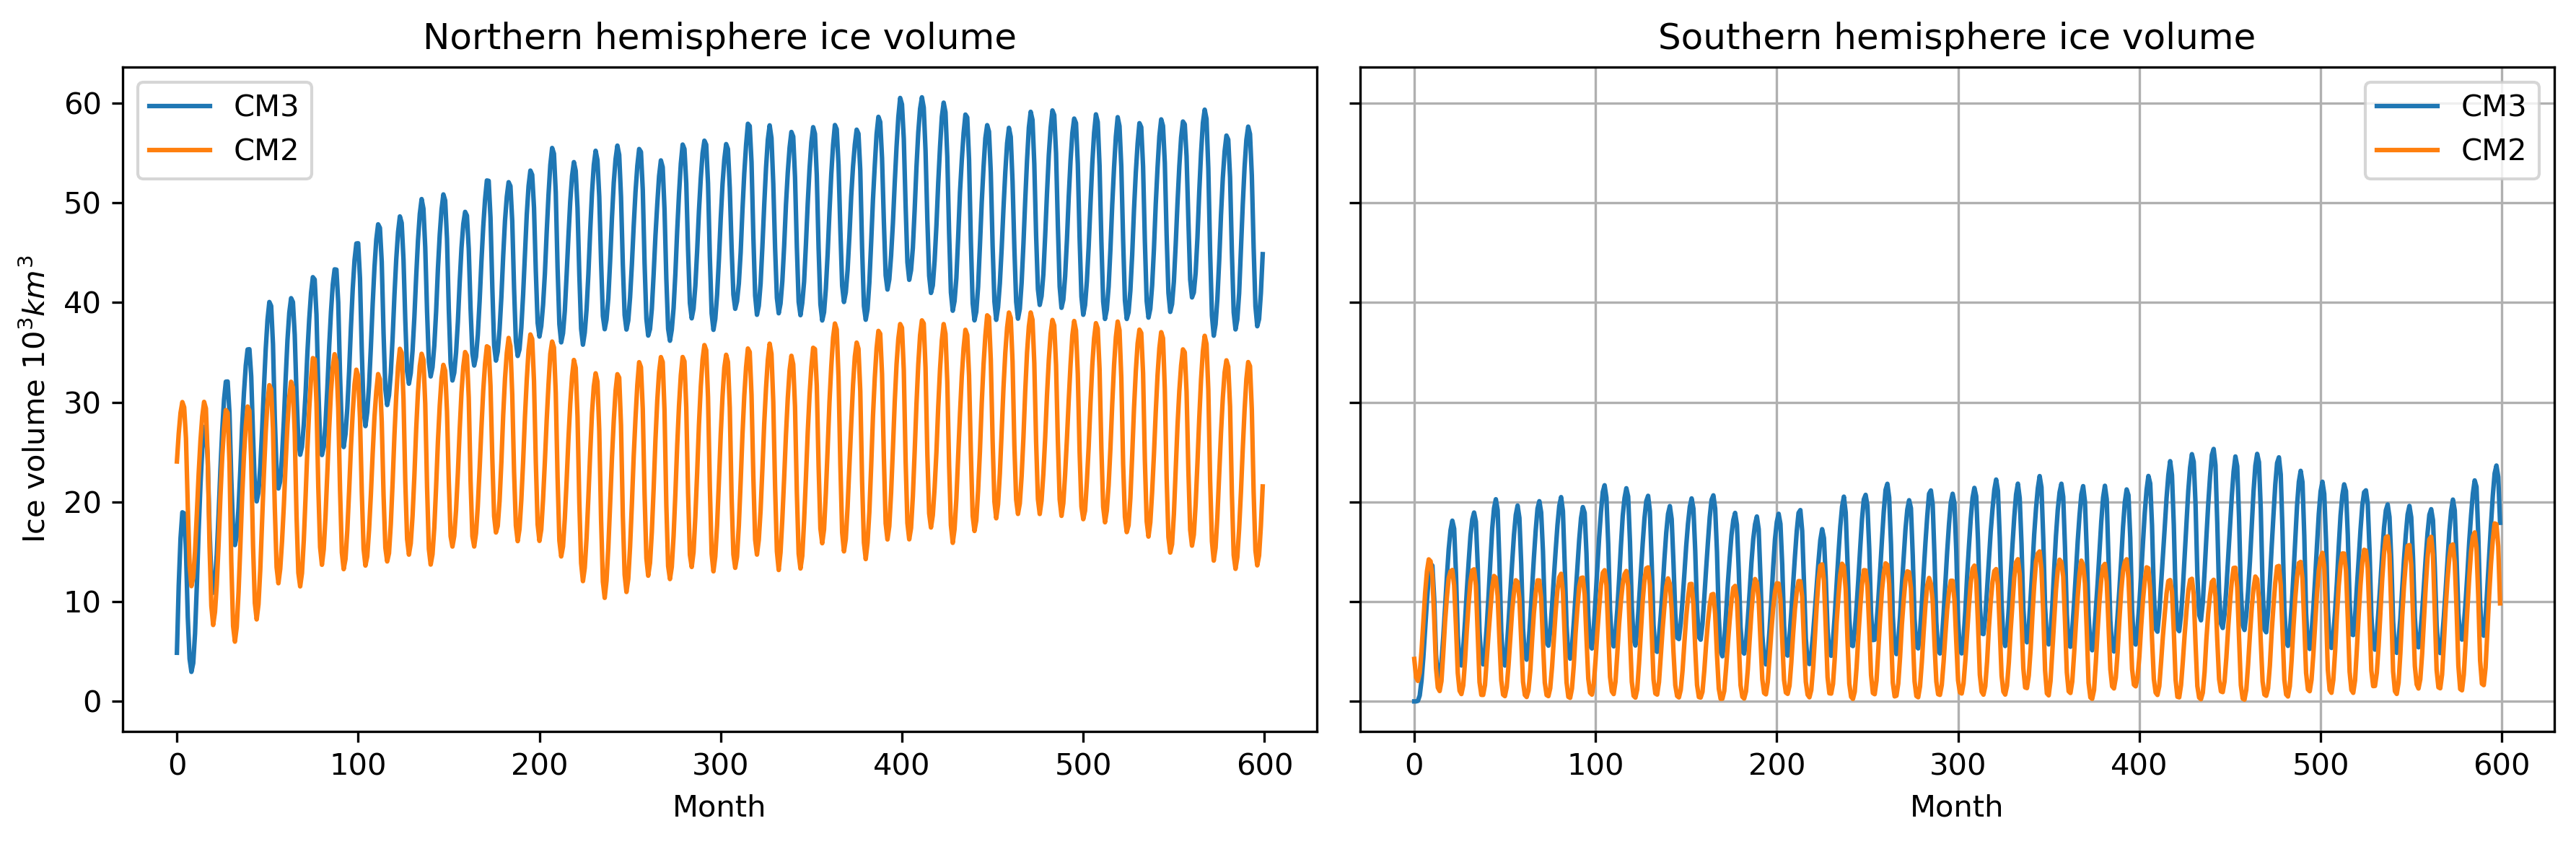

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(cm3_nh_ice_vol / 1e12, label='CM3')
ax1.plot(cm2_nh_ice_vol / 1e12, label='CM2')
ax2.plot(cm3_sh_ice_vol / 1e12, label='CM3')
ax2.plot(cm2_sh_ice_vol / 1e12, label='CM2')

ax1.set_title('Northern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()
plt.grid()

# Atmosphere time series

## Load UM data manually

Loading the UM data using the datastore can be slow, so we load the data manually instead.

In [41]:
archive_dir = os.path.join(os.path.split(os.path.split(esm_file)[0])[0], 'archive')
ds_list = []
year_start = 1981
year_end = year_start + 49
for year in range(year_start, year_end + 1):
    for month in range(1, 13):
        # fp = os.path.join(ARCHIVE_DIR, f'{year}', 'atmosphere', f'atmosa.pm-{year}{str(month).zfill(2)}-mon.nc')
        try:
            fp = os.path.join(archive_dir, str(year), 'atmosphere', f'atmosa.pm-{year}{str(month).zfill(2)}-mon.nc')
            ds_list.append(h5py.File(fp, "r"))
        except(FileNotFoundError):
            print(fp)

In [42]:
%%time
sw_out = xr.DataArray(da.concatenate([da.from_array(ds["/fld_s01i208"]) for ds in ds_list]), dims=('time', 'lat', 'lon'))
lw_out = xr.DataArray(da.concatenate([da.from_array(ds["/fld_s02i205"]) for ds in ds_list]), dims=('time', 'lat', 'lon'))
sw_in = xr.DataArray(da.concatenate([da.from_array(ds["/fld_s01i207"]) for ds in ds_list]), dims=('time', 'lat', 'lon'))

CPU times: user 2.85 s, sys: 11.2 s, total: 14 s
Wall time: 1min 10s


In [43]:
toa = sw_in - sw_out - lw_out

In [44]:
%%time
avg_toa = toa.weighted(areacella).mean(dim=('lat', 'lon')).compute()

CPU times: user 13 s, sys: 1.9 s, total: 14.9 s
Wall time: 55.7 s


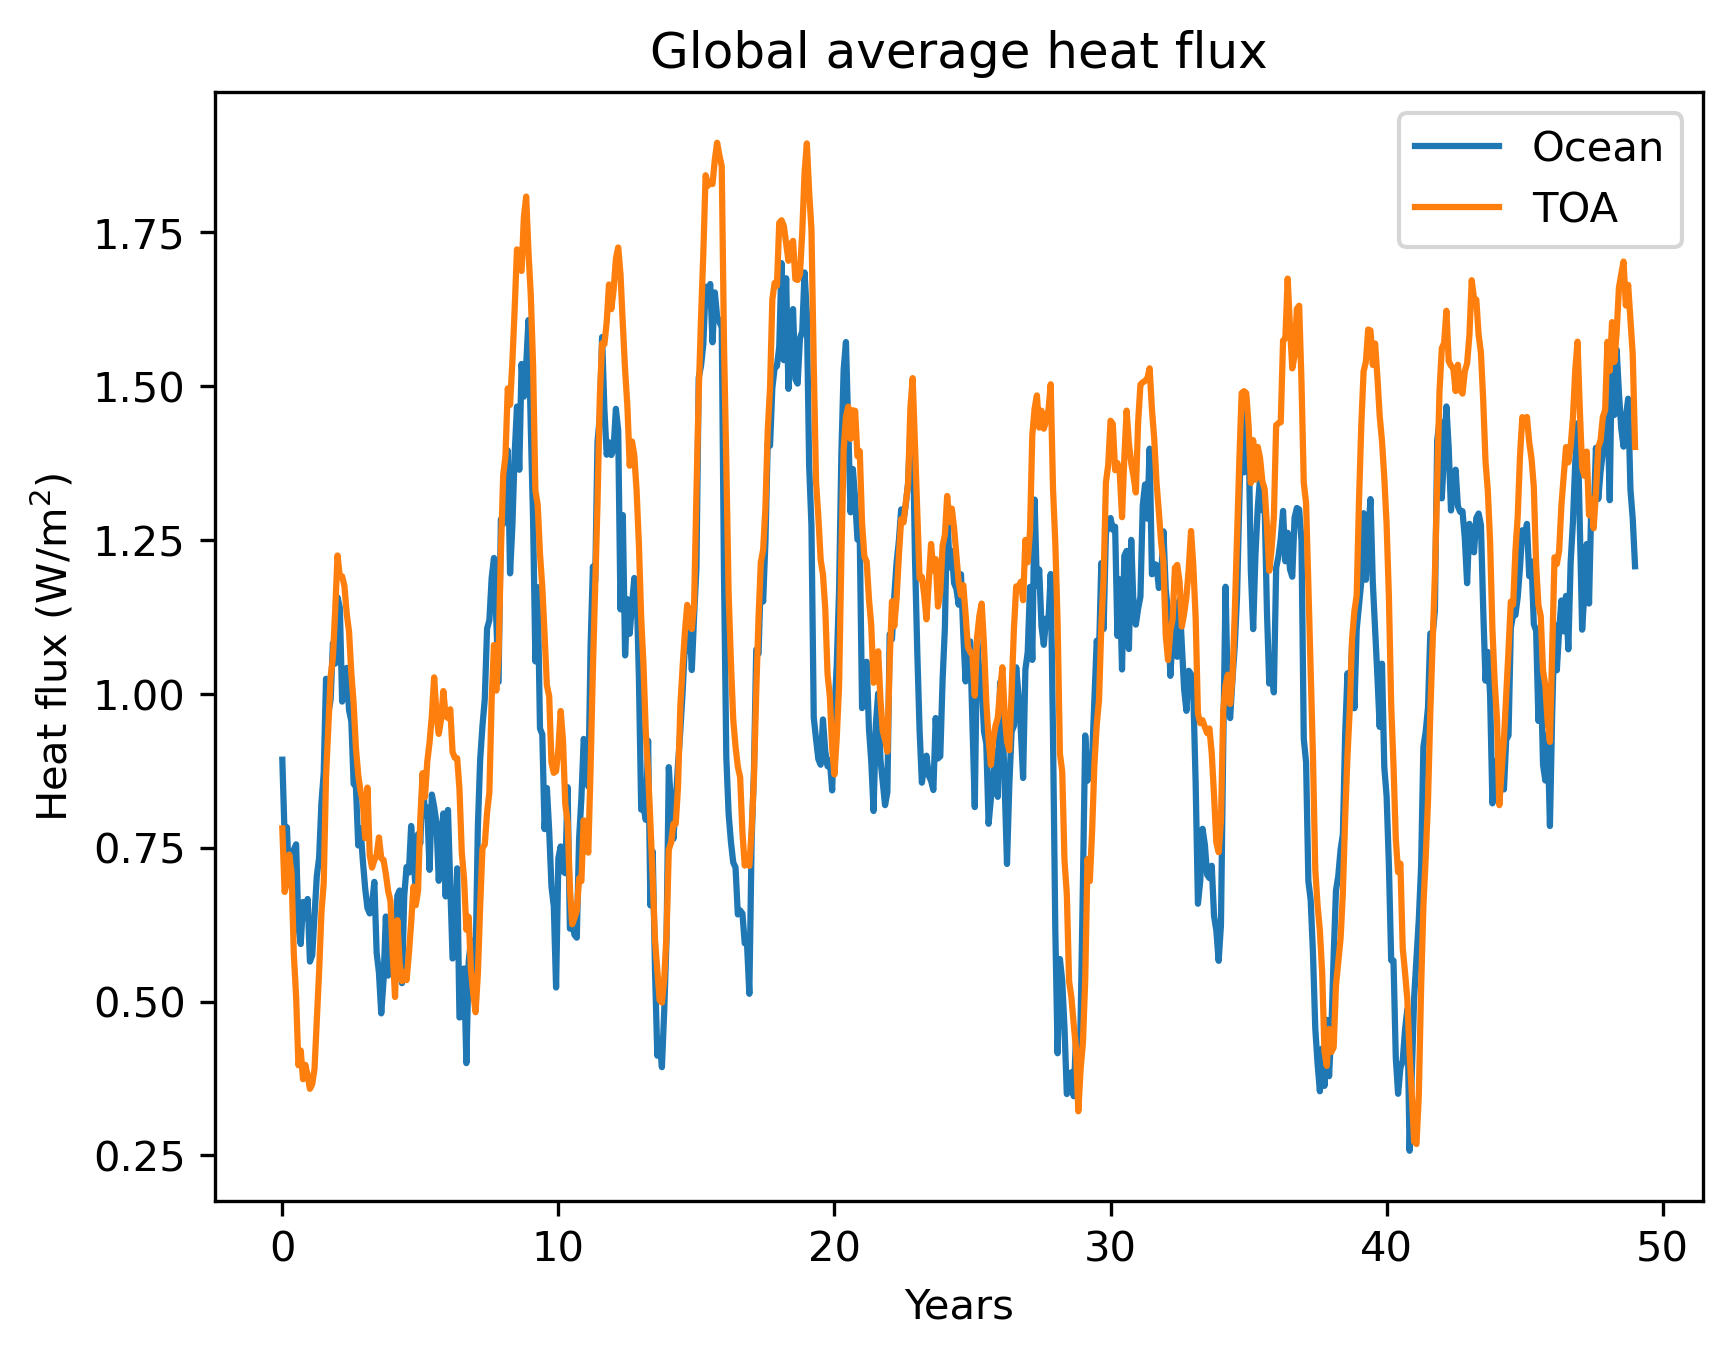

In [45]:
N = 12

rolling_avg = np.convolve(cm3_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='Ocean')

rolling_avg = np.convolve(avg_toa, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='TOA')

plt.title('Global average heat flux')

plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')
plt.legend()